# What is the most optimal skill to learn for Data Analyst?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting 
2. Visualize median salary vs percent skill demand
3. (optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries 
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter,FuncFormatter
from adjustText import adjust_text

In [2]:
# Loading Dataset
raw = load_dataset('lukebarousse/data_jobs')
df = raw['train'].to_pandas().copy()

In [3]:
# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
# Filtering Dataset for Data Analysts jobs in the US
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].dropna(subset='salary_year_avg',axis=0)

In [12]:
df_explode = df_DA_US.explode('job_skills') 

In [ ]:
df_grp = df_explode.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_grp = df_grp.rename(columns={'count':'skill_count','median':'median_salary'})

df_job_count = len(df_DA_US)

df_grp['skill_percent'] = df_grp['skill_count']/df_job_count*100
df_grp

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [31]:
skill_percentage = 6
df_perc = df_grp[df_grp['skill_percent'] > skill_percentage]
df_perc

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


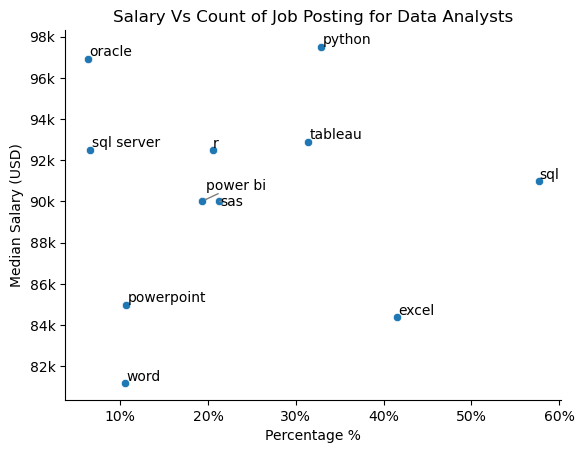

In [36]:
sns.scatterplot(data=df_perc,x='skill_percent',y='median_salary')
sns.despine()

plt.ylabel('Median Salary (USD)')
plt.xlabel('Percentage %')
plt.title('Salary Vs Count of Job Posting for Data Analysts')

ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos:f'{int(y/1000)}k'))

text=[]
for i,txt in enumerate(df_perc.index):
    text.append(plt.text(df_perc['skill_percent'].iloc[i],df_perc['median_salary'].iloc[i],txt))

adjust_text(text,arrowprops=dict(arrowstyle='->',color='grey',lw=1))

plt.show()

### 

### Things to learn

In [37]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology =df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictonaries into one
technology_dict ={}
for row in df_technology:
    row_dict = ast.literal_eval(row) # converting srting to dictionary 
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spreadsheet',
  'esquisse',
  'sas',
  'sap',
  'powerbi',
  'splunk',
  'dax',
  'excel',
  'word',
  'looker',
  'ms access',
  'msaccess',
  'qlik',
  'spss',
  'ssrs',
  'tableau',
  'power bi',
  'alteryx',
  'powerpoint',
  'outlook',
  'microstrategy',
  'datarobot',
  'sharepoint',
  'visio',
  'nuix',
  'cognos',
  'ssis',
  'sheets'],
 'programming': ['powershell',
  'kotlin',
  'javascript',
  'visualbasic',
  'julia',
  'groovy',
  'shell',
  'css',
  'clojure',
  'python',
  'mongo',
  'perl',
  'golang',
  'solidity',
  'nosql',
  'sas',
  'fortran',
  'no-sql',
  'bash',
  'php',
  'go',
  'matlab',
  'vba',
  'html',
  'crystal',
  'haskell',
  'swift',
  'ruby',
  'vb.net',
  'cobol',
  'apl',
  'lisp',
  'typescript',
  't-sql',
  'sass',
  'dart',
  'elixir',
  'ocaml',
  'lua',
  'visual basic',
  'sql',
  'c#',
  'objective-c',
  'r',
  'c',
  'c++',
  'java',
  'rust',
  'delphi',
  'erlang',
  'mongodb',
  'pascal',
  'f#',
  'assembly',
  'sc

In [38]:
df_technology = pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spreadsheet
0,analyst_tools,esquisse
0,analyst_tools,sas
0,analyst_tools,sap
0,analyst_tools,powerbi
...,...,...
9,sync,wire
9,sync,ringcentral
9,sync,microsoft teams
9,sync,mattermost


In [46]:
df_DA_skills_high_demand = df_perc.merge(df_technology,left_on='job_skills',right_on='skills')
df_DA_skills_high_demand = df_DA_skills_high_demand.drop(index=4).reset_index().drop('index',axis=1)
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,programming,sas
5,893,92500.00,20.528736,programming,r
6,838,90000.00,19.264368,analyst_tools,power bi
7,462,85000.00,10.620690,analyst_tools,powerpoint
8,461,81194.75,10.597701,analyst_tools,word
9,286,92500.00,6.574713,databases,sql server


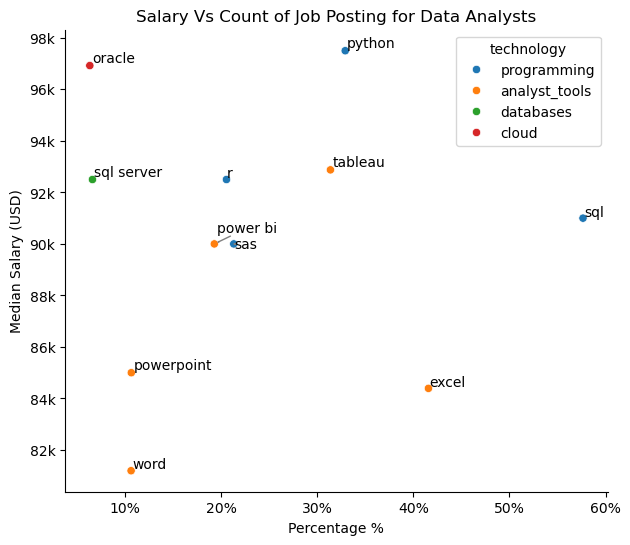

In [54]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df_DA_skills_high_demand,x='skill_percent',y='median_salary',hue='technology')
sns.despine()

plt.ylabel('Median Salary (USD)')
plt.xlabel('Percentage %')
plt.title('Salary Vs Count of Job Posting for Data Analysts')

ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos:f'{int(y/1000)}k'))

text=[]
for i,txt in enumerate(df_DA_skills_high_demand['skills']):
    text.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i],df_DA_skills_high_demand['median_salary'].iloc[i],txt))

adjust_text(text,arrowprops=dict(arrowstyle='->',color='grey',lw=1))

plt.show()